# Load Packages and Data

In [204]:
from data import build_all
from pitch_suggestions import suggest_pitches, plot_pitch_clusters, run_suggest_pitches_bulk
import warnings
import pandas as pd

from biomech import compute_euclidean_distances

pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")

In [203]:
import importlib
import pitch_suggestions

importlib.reload(pitch_suggestions)

<module 'pitch_suggestions' from '/Users/kids/Pitcher Similarity/pitch_suggestions.py'>

In [88]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

# Identify Pitch Opportunities

In [89]:
BIOMECH_FEATURES    = ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']
PITCH_CHAR_FEATURES = ['release_speed', 'pfx_x', 'pfx_z']

### Bello Example

Example of what the tool recommends

In [137]:
b_bello = suggest_pitches(
    target_pitcher='Bello, Brayan',
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_r,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [138]:
b_bello['status']

'ok'

In [139]:
b_bello['target_info']

pitcher                        678394
p_throws                            R
player_name             Bello, Brayan
game_year                        2025
release_pos_x               -1.657082
release_pos_z                5.323063
release_extension            6.342714
arm_angle                   32.793504
n                                2697
max_velo                    95.301591
max_spin                  2479.262411
pri_fb                             SI
fb_pfx_x                    -1.408565
fb_n                            943.0
pri_fb_cd                           0
active_spin_fastball             80.8
FB_type                            FF
Name: 3714, dtype: object

In [190]:
b_bello['comps'].sort_values('comp_pitcher')[20:25]

,comp_pitcher,comp_year,distance
19,"Beasley, Jeremy",2021,0.538652
209,"Bellatti, Andrew",2023,1.284690
5,"Bello, Brayan",2025,0.379836
274,"Bender, Anthony",2024,1.415107
198,"Berríos, José",2022,1.257038


In [141]:
print(b_bello['comp_pitches'].shape)
b_bello['comp_pitches'].head()

(48, 16)


,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_sil,cluster_label,biomech_distance,sim_weight
3,"Duffey, Tyler",2021,CS,73.983721,0.961163,-1.079070,43,1052,0.040875,2.556191,ST,1,0.612139,CU,1.135869,0.880382
4,"Scherzer, Max",2021,CU,76.863538,1.120650,-0.661625,277,2821,0.098192,1.810144,ST,1,0.525505,CU,1.168811,0.855570
5,"Darvish, Yu",2023,CU,72.575490,0.997157,-1.292745,102,2208,0.046196,2.959243,ST,1,0.570373,CU,0.946487,1.056537
6,"Mikolas, Miles",2024,CU,76.587580,0.664395,-1.182548,314,2697,0.116426,2.245386,ST,1,0.698466,CU,1.306019,0.765685
7,"Smith, Burch",2024,CU,79.996951,0.920366,-1.140183,164,896,0.183036,1.740989,ST,1,0.736015,CU,1.443101,0.692952


In [142]:
b_bello['suggestions']

,cluster_label,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,_sil,pitch_types_in_cluster,comp_pitchers
0,CU,47,78.4,0.94,-1.07,1.94,78.6,0.94,-1.06,0.649,"CS, CU, KC","Antone, Tejay, Avila, Pedro, Barlow, Scott, Ba..."


In [143]:
b_bello['target_pitches']

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Bello, Brayan",2025,CH,88.787073,-1.336869,0.377049,410
1,"Bello, Brayan",2025,FC,88.241371,0.072411,0.215721,423
2,"Bello, Brayan",2025,FF,95.075980,-0.638393,1.126201,408
3,"Bello, Brayan",2025,SI,95.301591,-1.408565,0.471697,943
4,"Bello, Brayan",2025,ST,85.676608,0.825887,-0.265263,513


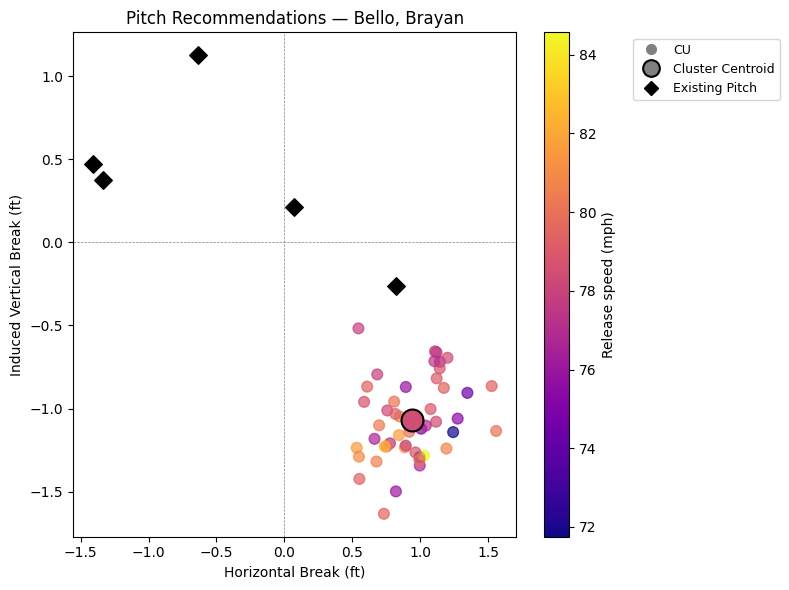

In [144]:
plot_pitch_clusters(b_bello)

## Bulk runs

In [153]:
l_bulk = run_suggest_pitches_bulk(pitcher_summ_l, pitch_type_summ, 
                                  min_pitches=20,
                                  biomech_distance_threshold=1.5,  
                                  novelty_distance_threshold=1.5,  
                                  min_comp_usage_pct=0.01)

In [160]:
print(len(l_bulk[0]), "New suggestions for lefties")
l_bulk[0].head()

296 New suggestions for lefties


,target_pitcher,cluster_label,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,_sil,pitch_types_in_cluster,comp_pitchers
0,"Hill, Rich",CU,8,78.7,-0.53,-0.28,1.72,78.7,-0.52,-0.28,0.352,"CU, KC, SL, SV","Bleier, Richard, Fleming, Josh, Freeland, Kyle..."
1,"Hill, Rich",ST,6,79.0,-1.21,-0.00,1.66,79.0,-1.22,-0.02,0.366,"SL, ST","Bruihl, Justin, Díaz, Jhonathan, Guenther, Sea..."
2,"Hill, Rich",SL,5,81.7,-0.75,-0.25,1.66,81.7,-0.78,-0.26,0.343,"CU, SL","Alexander, Scott, Alexander, Tyler, Garrett, B..."
3,"Wilson, Justin",CU,66,78.7,-0.77,-0.70,2.30,78.4,-0.76,-0.73,0.731,"CU, KC, SL, ST, SV","Abad, Fernando, Abbott, Andrew, Allard, Kolby,..."
4,"Wilson, Justin",SI,10,93.0,1.34,0.86,1.59,92.4,1.33,0.89,0.837,"CH, SI","Banuelos, Manny, Borucki, Ryan, Jay, Tyler, Ma..."


In [155]:
l_bulk[1]

,target_pitcher,status,n_comps,n_suggestions
0,"Hill, Rich",ok,33,3
1,"Wilson, Justin",ok,115,2
2,"Kershaw, Clayton",ok,28,2
3,"Miley, Wade",ok,142,2
4,"Quintana, Jose",ok,102,2
...,...,...,...,...
202,"Sommers, Drew",no_comps,0,0
203,"Gibson, Cade",no_novel_pitches,113,0
204,"Early, Connelly",ok,62,1
205,"Farris, Mitch",ok,81,2


In [179]:
l_bulk[0][(l_bulk[0]['_sil'] > 0.3) & (l_bulk[0]['_sil'] < 0.34)]

,target_pitcher,cluster_label,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,_sil,pitch_types_in_cluster,comp_pitchers
18,"Anderson, Tyler",KC,2,76.0,-1.16,-0.29,1.65,76.0,-1.15,-0.31,0.338,"KC, ST","Means, John, Springs, Jeffrey"
121,"Newcomb, Sean",CU,5,81.1,-0.24,0.11,1.56,81.2,-0.24,0.10,0.335,"CU, KC, SL","Lauer, Eric, Logue, Zach, Smyly, Drew, Suarez,..."
153,"Holton, Tyler",CH,3,80.0,0.29,0.52,1.51,79.6,0.24,0.45,0.338,"CH, CU, KC","Holland, Derek, Lucchesi, Joey, Means, John"


In [177]:
s_peralta = suggest_pitches(
    target_pitcher='Peralta, Sammy',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [175]:
e_lauer = suggest_pitches(
    target_pitcher='Lauer, Eric',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [173]:
r_hill = suggest_pitches(
    target_pitcher='Hill, Rich',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [163]:
p_corbin = suggest_pitches(
    target_pitcher='Corbin, Patrick',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [199]:
t_alexander = suggest_pitches(
    target_pitcher='Alexander, Tyler',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [168]:
j_beeks = suggest_pitches(
    target_pitcher='Beeks, Jalen',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [170]:
r_garcia = suggest_pitches(
    target_pitcher='Garcia, Robert',
    pitcher_summ=pitcher_summ_l,        
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

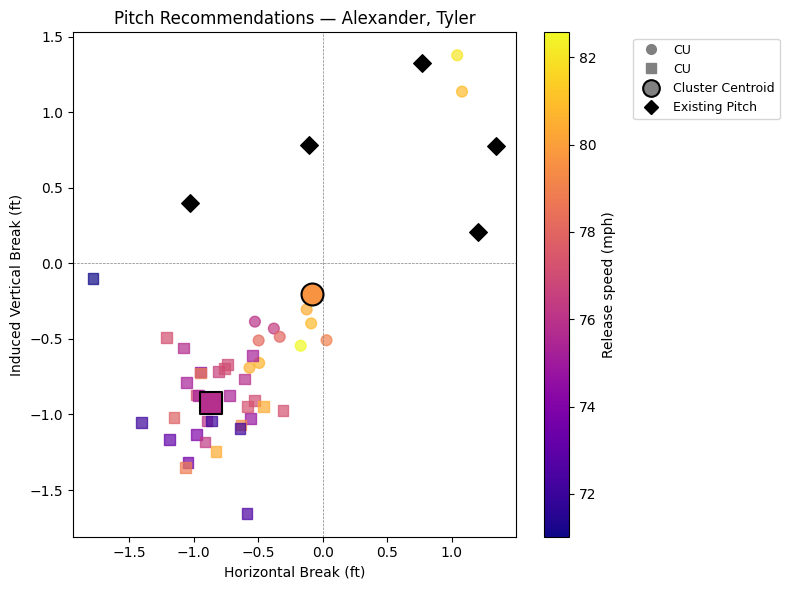

In [205]:
plot_pitch_clusters(t_alexander)

In [191]:
t_alexander['comps'].sort_values('comp_pitcher')[3:7]

,comp_pitcher,comp_year,distance
89,"Alexander, Scott",2022,1.376444
8,"Alexander, Tyler",2025,0.603799
51,"Allard, Kolby",2025,1.110445
1,"Allen, Logan",2025,0.355586


In [206]:
t_alexander['comp_pitches'][t_alexander['comp_pitches']['cluster'] == 0]

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_sil,cluster_label,biomech_distance,sim_weight
0,"Anderson, Tyler",2021,CH,80.902184,1.078970,1.136771,641,2601,0.246444,1.564075,CH,0,0.309285,CU,1.333645,0.749824
1,"Means, John",2024,CH,82.049451,1.041978,1.377253,91,320,0.284375,1.649081,FF,0,0.293612,CU,1.090923,0.916654
3,"Happ, J.A.",2021,CU,76.366667,-0.378182,-0.431212,33,2673,0.012346,1.681487,ST,0,-0.027052,CU,0.924002,1.082247
4,"Quintana, Jose",2025,CU,78.198734,-0.495949,-0.510063,316,2174,0.145354,1.621215,ST,0,0.000596,CU,1.000868,0.999132
9,"Gonzales, Marco",2024,CU,79.043636,0.029636,-0.508545,55,546,0.100733,1.899881,ST,0,0.269254,CU,1.156046,0.865017
25,"Akin, Keegan",2021,CU,76.023729,-0.524915,-0.385593,59,1768,0.033371,1.585660,ST,0,-0.110855,CU,1.463886,0.683113
27,"Henry, Tommy",2022,CU,80.567257,-0.566814,-0.690973,113,773,0.146184,1.823478,ST,0,-0.050380,CU,0.928186,1.077369
35,"Moore, Matt",2021,KC,80.718750,-0.491823,-0.659167,192,1254,0.153110,1.802948,ST,0,0.047805,CU,1.458070,0.685838
36,"Paxton, James",2024,KC,80.818182,-0.089149,-0.397176,517,1708,0.302693,1.666433,ST,0,0.363405,CU,1.497439,0.667806
37,"Freeland, Kyle",2025,KC,82.574537,-0.170556,-0.545015,648,2482,0.261080,1.849569,ST,0,0.272933,CU,0.866293,1.154342


In [201]:
t_alexander['comp_pitches']

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_sil,cluster_label,biomech_distance,sim_weight
0,"Anderson, Tyler",2021,CH,80.902184,1.078970,1.136771,641,2601,0.246444,1.564075,CH,0,0.309285,CU,1.333645,0.749824
1,"Means, John",2024,CH,82.049451,1.041978,1.377253,91,320,0.284375,1.649081,FF,0,0.293612,CU,1.090923,0.916654
2,"Hill, Rich",2023,CU,72.063318,-1.400619,-1.051986,856,2373,0.360725,2.804952,ST,1,0.544013,CU,1.126104,0.888017
3,"Happ, J.A.",2021,CU,76.366667,-0.378182,-0.431212,33,2673,0.012346,1.681487,ST,0,-0.027052,CU,0.924002,1.082247
4,"Quintana, Jose",2025,CU,78.198734,-0.495949,-0.510063,316,2174,0.145354,1.621215,ST,0,0.000596,CU,1.000868,0.999132
5,"Smith, Will",2022,CU,76.905556,-0.738333,-0.670889,90,985,0.091371,1.850733,ST,1,0.409561,CU,1.074561,0.930612
6,"Ryu, Hyun Jin",2021,CU,73.974303,-0.979969,-1.130341,323,2681,0.120477,2.710268,ST,1,0.619913,CU,1.175346,0.850812
7,"Boyd, Matthew",2021,CU,73.503125,-1.042500,-1.319896,96,1272,0.075472,3.021910,ST,1,0.582342,CU,0.531327,1.882076
8,"Dayton, Grant",2021,CU,77.225287,-0.307011,-0.972644,87,250,0.348000,2.410352,ST,1,0.364491,CU,1.075071,0.930171
9,"Gonzales, Marco",2024,CU,79.043636,0.029636,-0.508545,55,546,0.100733,1.899881,ST,0,0.269254,CU,1.156046,0.865017


In [202]:
t_alexander['suggestions']

,cluster_label,cluster,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,_sil,pitch_types_in_cluster,comp_pitchers
0,CU,1,31,75.8,-0.87,-0.93,2.35,75.7,-0.88,-0.95,0.483,"CU, KC, ST","Aldegheri, Sam, Allard, Kolby, Boyd, Matthew, ..."
1,CU,0,12,79.6,-0.09,-0.20,1.70,79.7,-0.10,-0.22,0.156,"CH, CU, KC, SL","Akin, Keegan, Anderson, Tyler, Freeland, Kyle,..."
